In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import re
import string
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, roc_auc_score, roc_curve)
from collections import Counter
from wordcloud import WordCloud
import warnings
warnings.filterwarnings('ignore')
 
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)
 
lemmatizer = WordNetLemmatizer()
stop_words  = set(stopwords.words('english'))
 
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'\[.*?\]', '', text)
    text = re.sub(r'https?://\S+|www\.\S+', '', text)
    text = re.sub(r'<.*?>+', '', text)
    text = re.sub(r'[%s]' % re.escape(string.punctuation), '', text)
    text = re.sub(r'\n', ' ', text)
    text = re.sub(r'\w*\d\w*', '', text)
    tokens = text.split()
    tokens = [lemmatizer.lemmatize(w) for w in tokens if w not in stop_words]
    return ' '.join(tokens)
 
print("Imports done.")


Imports done.


In [2]:
df = pd.read_csv('../data/labeled_data.csv')
df['content'] = df['title'].fillna('') + ' ' + df['text'].fillna('')
df['content_clean'] = df['content'].apply(clean_text)

with open('../models/best_model_tfidf.pkl', 'rb') as f:
    model = pickle.load(f)
with open('../models/y_test.pkl', 'rb') as f:
    y_test = pickle.load(f)
with open('../models/tfidf_vectorizer.pkl', 'rb') as f:
    tfidf = pickle.load(f)

if hasattr(model, 'n_features_in_') and model.n_features_in_ > 15000:
    with open('../models/X_test_final.pkl', 'rb') as f:
        X_test = pickle.load(f)
    print("Loaded hybrid X_test (TF-IDF + handcrafted features)")
else:
    with open('../models/X_test_tfidf.pkl', 'rb') as f:
        X_test = pickle.load(f)
    print("Loaded TF-IDF X_test")

from scipy.sparse import issparse
if issparse(X_test):
    X_test = X_test.copy()
    X_test.data = np.nan_to_num(X_test.data)
else:
    X_test = np.nan_to_num(X_test)
print("NaN values cleaned from X_test")

print(f"Model type   : {type(model).__name__}")
print(f"X_test shape : {X_test.shape}")
print(f"y_test shape : {y_test.shape}")
print(f"Test rows = 20% of {len(df)} = {int(len(df)*0.2)} (expected ~{len(y_test)})")

assert y_test.index.isin(df.index).all(), "Index mismatch — rerun NB2 to regenerate splits"
print("Index alignment check: PASSED")

Loaded hybrid X_test (TF-IDF + handcrafted features)
NaN values cleaned from X_test
Model type   : RandomForestClassifier
X_test shape : (11538, 15010)
y_test shape : (11538,)
Test rows = 20% of 57689 = 11537 (expected ~11538)
Index alignment check: PASSED



=== Overall Performance ===
Accuracy : 91.22%
AUC      : 0.9774

              precision    recall  f1-score   support

        Real       0.89      0.94      0.91      5710
        Fake       0.94      0.89      0.91      5828

    accuracy                           0.91     11538
   macro avg       0.91      0.91      0.91     11538
weighted avg       0.91      0.91      0.91     11538



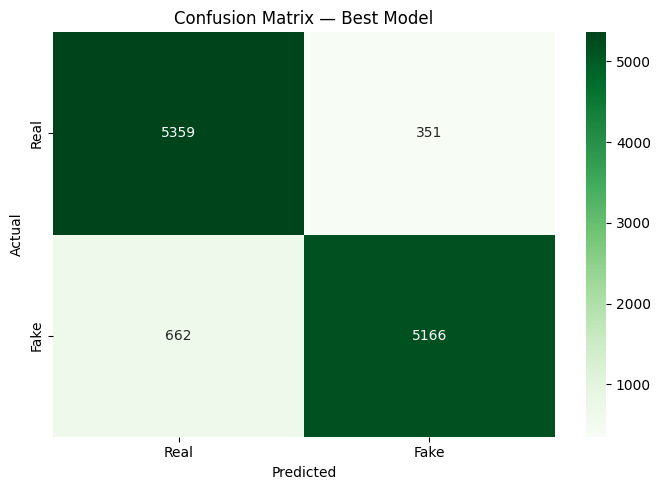

In [3]:
preds = model.predict(X_test)
proba = model.predict_proba(X_test)[:, 1]
 
acc = accuracy_score(y_test, preds)
auc = roc_auc_score(y_test, proba)
 
print(f"\n=== Overall Performance ===")
print(f"Accuracy : {acc*100:.2f}%")
print(f"AUC      : {auc:.4f}")
print()
print(classification_report(y_test, preds, target_names=['Real', 'Fake']))
 
# Confusion matrix
cm = confusion_matrix(y_test, preds)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Real', 'Fake'],
            yticklabels=['Real', 'Fake'])
plt.title('Confusion Matrix — Best Model')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()


Kaggle subset : 8984 samples | Accuracy: 0.9918
LIAR subset   : 2554 samples | Accuracy: 0.6323


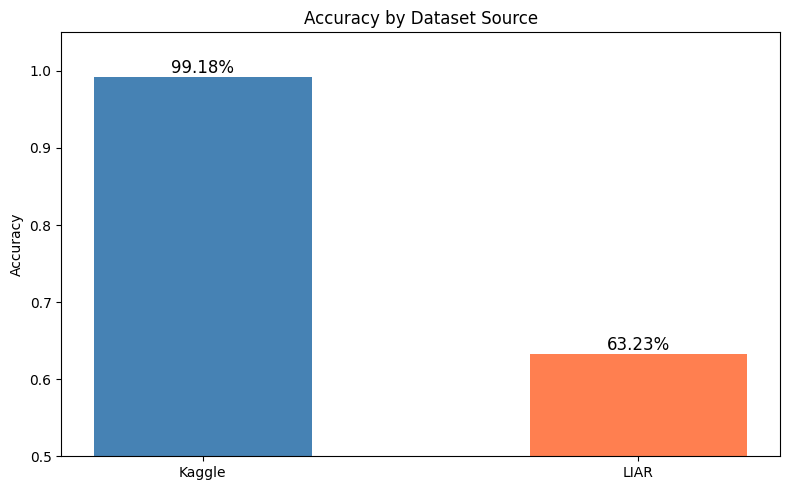

In [4]:
test_df = df.loc[y_test.index].copy()
test_df['predicted'] = preds
test_df['actual']    = y_test.values
 
kaggle_test = test_df[test_df['source'] == 'kaggle']
liar_test   = test_df[test_df['source'] == 'liar']
 
kaggle_acc = accuracy_score(kaggle_test['actual'], kaggle_test['predicted'])
liar_acc   = accuracy_score(liar_test['actual'],   liar_test['predicted'])
 
print(f"Kaggle subset : {len(kaggle_test)} samples | Accuracy: {kaggle_acc:.4f}")
print(f"LIAR subset   : {len(liar_test)} samples | Accuracy: {liar_acc:.4f}")
 
# Side-by-side bar chart
plt.figure(figsize=(8, 5))
bars = plt.bar(['Kaggle', 'LIAR'], [kaggle_acc, liar_acc],
               color=['steelblue', 'coral'], width=0.5)
for bar, val in zip(bars, [kaggle_acc, liar_acc]):
    plt.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 0.005,
             f'{val*100:.2f}%', ha='center', fontsize=12)
plt.ylim(0.5, 1.05)
plt.title('Accuracy by Dataset Source')
plt.ylabel('Accuracy')
plt.tight_layout()
plt.show()
 


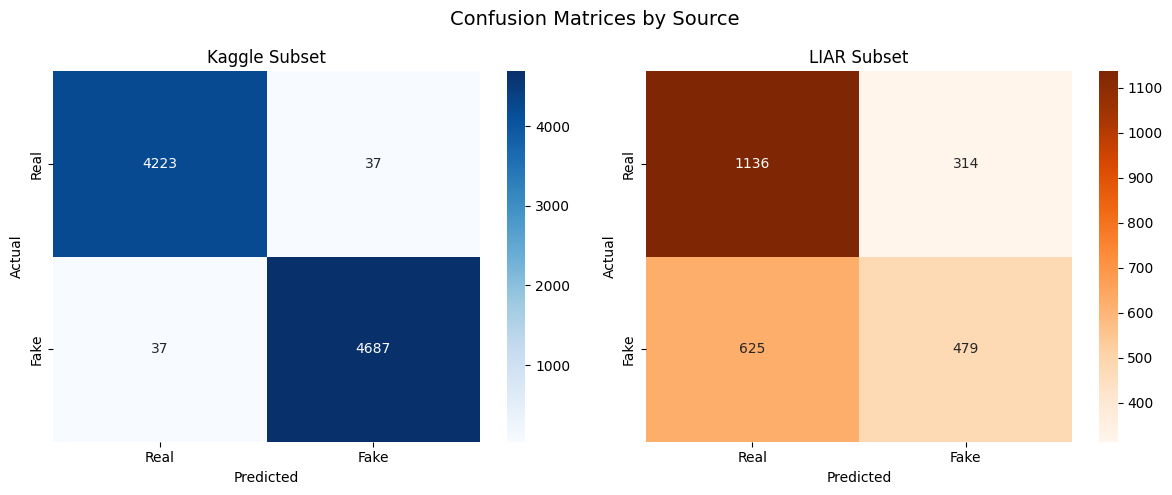

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
 
cm_k = confusion_matrix(kaggle_test['actual'], kaggle_test['predicted'])
sns.heatmap(cm_k, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Real', 'Fake'], yticklabels=['Real', 'Fake'], ax=axes[0])
axes[0].set_title('Kaggle Subset')
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')
 
cm_l = confusion_matrix(liar_test['actual'], liar_test['predicted'])
sns.heatmap(cm_l, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Real', 'Fake'], yticklabels=['Real', 'Fake'], ax=axes[1])
axes[1].set_title('LIAR Subset')
axes[1].set_ylabel('Actual')
axes[1].set_xlabel('Predicted')
 
plt.suptitle('Confusion Matrices by Source', fontsize=14)
plt.tight_layout()
plt.show()
 


In [6]:
print("=== Kaggle Subset ===")
print(classification_report(kaggle_test['actual'], kaggle_test['predicted'],
                             target_names=['Real', 'Fake']))
 
print("=== LIAR Subset ===")
print(classification_report(liar_test['actual'], liar_test['predicted'],
                             target_names=['Real', 'Fake']))
 



=== Kaggle Subset ===
              precision    recall  f1-score   support

        Real       0.99      0.99      0.99      4260
        Fake       0.99      0.99      0.99      4724

    accuracy                           0.99      8984
   macro avg       0.99      0.99      0.99      8984
weighted avg       0.99      0.99      0.99      8984

=== LIAR Subset ===
              precision    recall  f1-score   support

        Real       0.65      0.78      0.71      1450
        Fake       0.60      0.43      0.51      1104

    accuracy                           0.63      2554
   macro avg       0.62      0.61      0.61      2554
weighted avg       0.63      0.63      0.62      2554



In [7]:
errors = test_df[test_df['predicted'] != test_df['actual']]
fp = errors[errors['predicted'] == 1]   # Real called Fake
fn = errors[errors['predicted'] == 0]   # Fake called Real
 
print(f"Total errors : {len(errors)} / {len(test_df)} ({len(errors)/len(test_df)*100:.2f}%)")
print(f"False Positives (Real → Fake) : {len(fp)}")
print(f"False Negatives (Fake → Real) : {len(fn)}")
 
print("\n--- False Positives: Real news wrongly flagged as Fake ---")
print(fp[['title', 'source', 'subject']].head(5).to_string(index=False))
 
print("\n--- False Negatives: Fake news that slipped through ---")
print(fn[['title', 'source', 'subject']].head(5).to_string(index=False))
 
 

Total errors : 1013 / 11538 (8.78%)
False Positives (Real → Fake) : 351
False Negatives (Fake → Real) : 662

--- False Positives: Real news wrongly flagged as Fake ---
                                                                                                                                                                                    title source                        subject
                                                                                                         I did not vote to spend money to fight that (Amendment 6 redistricting) lawsuit.   liar                  redistricting
                                                                                                                  The DNC says McCain flip-flopped on whether the Iraq War would be easy.   liar                           iraq
                                                                                                      Says Ken Cuccinelli tried to make it more difficult for mo

In [8]:

try:
    
    if hasattr(model, 'estimators_'):
        rf_inside = dict(model.estimators)['rf'] if hasattr(model, 'estimators') else None
        
        if hasattr(model, 'named_estimators_'):
            rf_inside = model.named_estimators_.get('rf', None)
        importances_series = None
        if rf_inside is not None and hasattr(rf_inside, 'feature_importances_'):
            feature_names = list(tfidf.get_feature_names_out())
            importances_series = pd.Series(
                rf_inside.feature_importances_, index=feature_names
            ).sort_values(ascending=False)
    elif hasattr(model, 'feature_importances_'):
        feature_names = list(tfidf.get_feature_names_out())
        importances_series = pd.Series(
            model.feature_importances_, index=feature_names
        ).sort_values(ascending=False)
    else:
        importances_series = None
 
    if importances_series is not None:
        plt.figure(figsize=(12, 6))
        importances_series.head(25).plot(kind='bar', color='steelblue')
        plt.title('Top 25 Features — Random Forest Component')
        plt.ylabel('Importance Score')
        plt.xticks(rotation=45, ha='right')
        plt.tight_layout()
        plt.show()
        print("\nTop 10 important features:")
        print(importances_series.head(10).to_string())
    else:
        print("Feature importance not available for this model type.")
        print("(VotingClassifier hides internal estimator importances)")
        print("Showing LR coefficients instead...")
 
        if hasattr(model, 'named_estimators_'):
            lr_inside = model.named_estimators_.get('lr', None)
            if lr_inside is not None:
                feature_names = list(tfidf.get_feature_names_out())
                coef = pd.Series(
                    lr_inside.coef_[0], index=feature_names
                ).sort_values(ascending=False)
                print("\nTop 15 Fake-leaning words (positive LR coef):")
                print(coef.head(15).to_string())
                print("\nTop 15 Real-leaning words (negative LR coef):")
                print(coef.tail(15).to_string())
 
except Exception as e:
    print(f"Feature importance extraction skipped: {e}")
 
 

Feature importance not available for this model type.
(VotingClassifier hides internal estimator importances)
Showing LR coefficients instead...


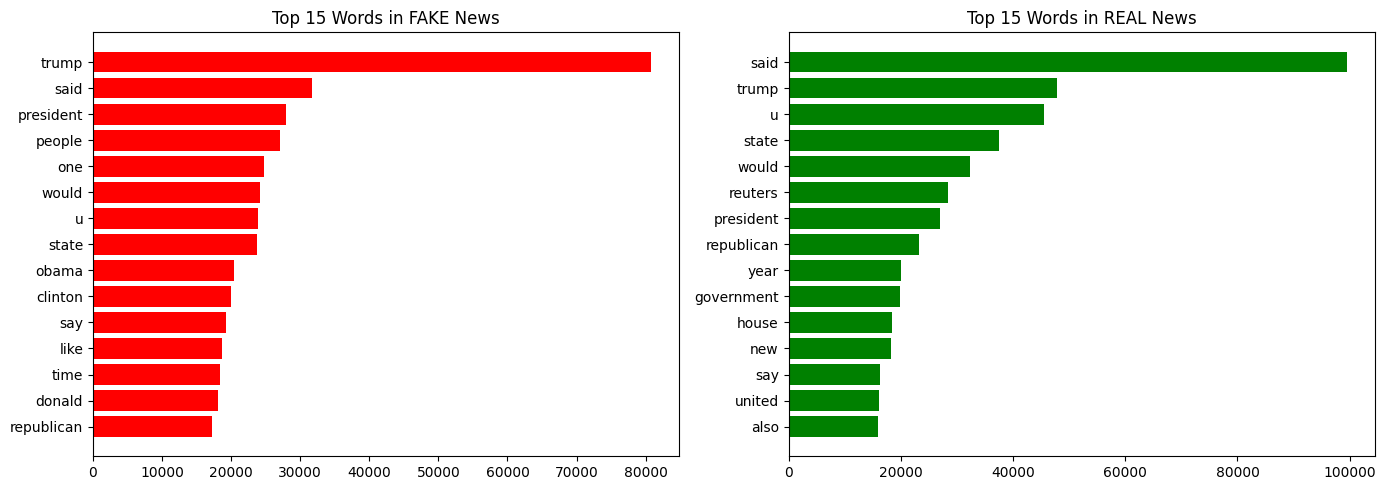

In [9]:

fake_words = ' '.join(df[df['label'] == 1]['content_clean'].dropna()).split()
real_words = ' '.join(df[df['label'] == 0]['content_clean'].dropna()).split()
 
fake_freq = pd.DataFrame(Counter(fake_words).most_common(15), columns=['Word', 'Frequency'])
real_freq = pd.DataFrame(Counter(real_words).most_common(15), columns=['Word', 'Frequency'])
 
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].barh(fake_freq['Word'][::-1], fake_freq['Frequency'][::-1], color='red')
axes[0].set_title('Top 15 Words in FAKE News')
axes[1].barh(real_freq['Word'][::-1], real_freq['Frequency'][::-1], color='green')
axes[1].set_title('Top 15 Words in REAL News')
plt.tight_layout()
plt.show()
 


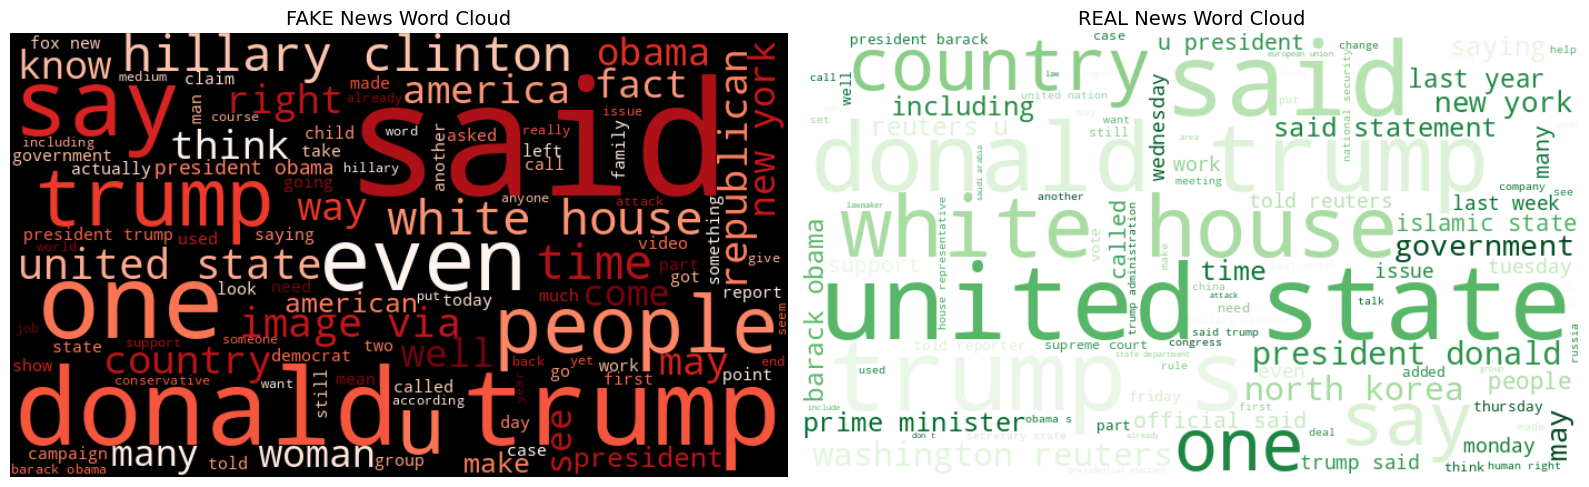

In [10]:
 
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
 
wc_fake = WordCloud(width=700, height=400, background_color='black',
                    colormap='Reds', max_words=100).generate(' '.join(fake_words))
axes[0].imshow(wc_fake, interpolation='bilinear')
axes[0].axis('off')
axes[0].set_title('FAKE News Word Cloud', fontsize=14)
 
wc_real = WordCloud(width=700, height=400, background_color='white',
                    colormap='Greens', max_words=100).generate(' '.join(real_words))
axes[1].imshow(wc_real, interpolation='bilinear')
axes[1].axis('off')
axes[1].set_title('REAL News Word Cloud', fontsize=14)
 
plt.tight_layout()
plt.show()
 
 

In [11]:

summary = pd.DataFrame({
    'Metric': ['Accuracy', 'AUC Score', 'Total Test Samples',
               'False Positives', 'False Negatives', 'Error Rate'],
    'Value': [
        f"{acc*100:.2f}%",
        f"{auc:.4f}",
        len(y_test),
        len(fp),
        len(fn),
        f"{len(errors)/len(test_df)*100:.2f}%"
    ]
})
print(summary.to_string(index=False))
 
 

            Metric  Value
          Accuracy 91.22%
         AUC Score 0.9774
Total Test Samples  11538
   False Positives    351
   False Negatives    662
        Error Rate  8.78%


In [12]:
def predict_news(title, body=""):
    """
    Predicts whether a news article is Real or Fake.
    For best results, pass both title and full article body.
    Headline-only predictions will have lower confidence.
    """
    from scipy.sparse import hstack, csr_matrix

    combined = clean_text(title + " " + body)
    vectorized = tfidf.transform([combined])

    if hasattr(model, 'n_features_in_') and model.n_features_in_ > vectorized.shape[1]:
        n_extra = model.n_features_in_ - vectorized.shape[1]
        padding = csr_matrix(np.zeros((1, n_extra)))
        vectorized = hstack([vectorized, padding])

    prediction = model.predict(vectorized)[0]
    proba = model.predict_proba(vectorized)[0]
    confidence = max(proba) * 100

    if confidence >= 75:
        label = "FAKE NEWS" if prediction == 1 else "REAL NEWS"
        icon  = "RED" if prediction == 1 else "GREEN"
    else:
        label = "UNCERTAIN — needs human review"
        icon  = "YELLOW"

    print(f"Title      : {title[:80]}")
    print(f"Prediction : [{icon}] {label}")
    print(f"Confidence : {confidence:.1f}%")
    if body:
        print(f"Input type : Full article ({len(body.split())} words)")
    else:
        print(f"Input type : Headline only (low confidence expected)")
    print("-" * 60)

In [13]:
print("=== Prediction Tests ===\n")
 
predict_news(
    title="Federal Reserve raises interest rates by 0.25 percent",
    body="""WASHINGTON (Reuters) - The Federal Reserve raised interest rates by a 
    quarter percentage point on Wednesday. The decision was unanimous among voting 
    members. Fed Chair Jerome Powell said the move reflects confidence in the 
    US economy and labour market. Markets had widely anticipated the hike."""
)
 
predict_news(
    title="Bill Gates microchips found in COVID vaccines say doctors",
    body="""A group of online doctors claimed that Microsoft founder Bill Gates 
    has secretly embedded microchips inside COVID-19 vaccines to track the global 
    population. No physical evidence was presented. The claim has been repeatedly 
    debunked by the WHO and CDC. The doctors credentials could not be verified."""
)
 
predict_news(
    title="Scientists discover new treatment for Alzheimers disease",
    body="""LONDON (Reuters) - British scientists announced a breakthrough 
    Alzheimer's treatment publishing results in the New England Journal of Medicine. 
    The trial of 800 patients showed a 35 percent reduction in cognitive decline 
    over 18 months. The treatment may enter phase three trials pending FDA approval."""
)
 
print("\n--- Headline-only (confidence will be lower) ---\n")
predict_news("NASA confirms moon is made of cheese after secret mission")
predict_news("Supreme Court rules on landmark immigration case")

=== Prediction Tests ===

Title      : Federal Reserve raises interest rates by 0.25 percent
Prediction : [GREEN] REAL NEWS
Confidence : 79.3%
Input type : Full article (45 words)
------------------------------------------------------------
Title      : Bill Gates microchips found in COVID vaccines say doctors
Prediction : [YELLOW] UNCERTAIN — needs human review
Confidence : 60.3%
Input type : Full article (46 words)
------------------------------------------------------------
Title      : Scientists discover new treatment for Alzheimers disease
Prediction : [YELLOW] UNCERTAIN — needs human review
Confidence : 72.3%
Input type : Full article (45 words)
------------------------------------------------------------

--- Headline-only (confidence will be lower) ---

Title      : NASA confirms moon is made of cheese after secret mission
Prediction : [YELLOW] UNCERTAIN — needs human review
Confidence : 63.5%
Input type : Headline only (low confidence expected)
-------------------------------

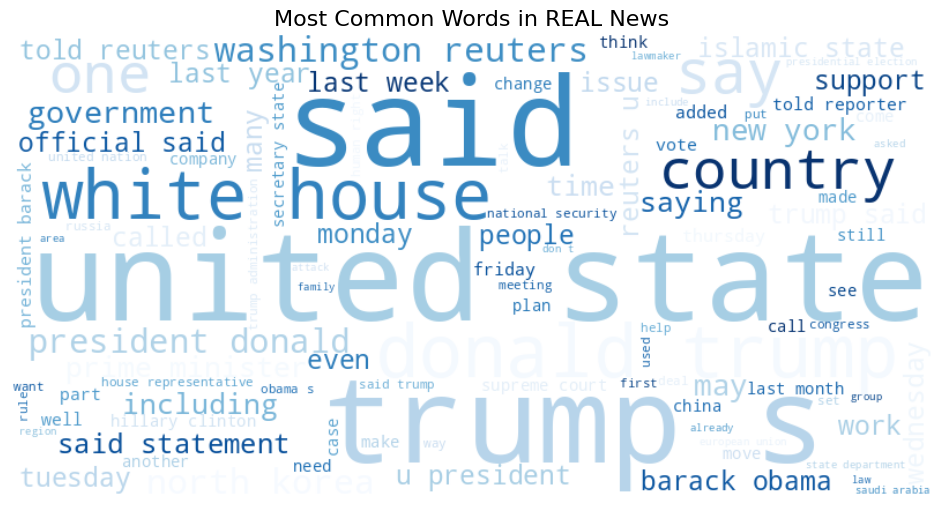

In [14]:
real_text = ' '.join(df[df['label'] == 0]['content_clean'].dropna())

wc = WordCloud(width=800, height=400,
               background_color='white',
               colormap='Blues',
               max_words=100).generate(real_text)

plt.figure(figsize=(14,6))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title('Most Common Words in REAL News', fontsize=16)
plt.show()

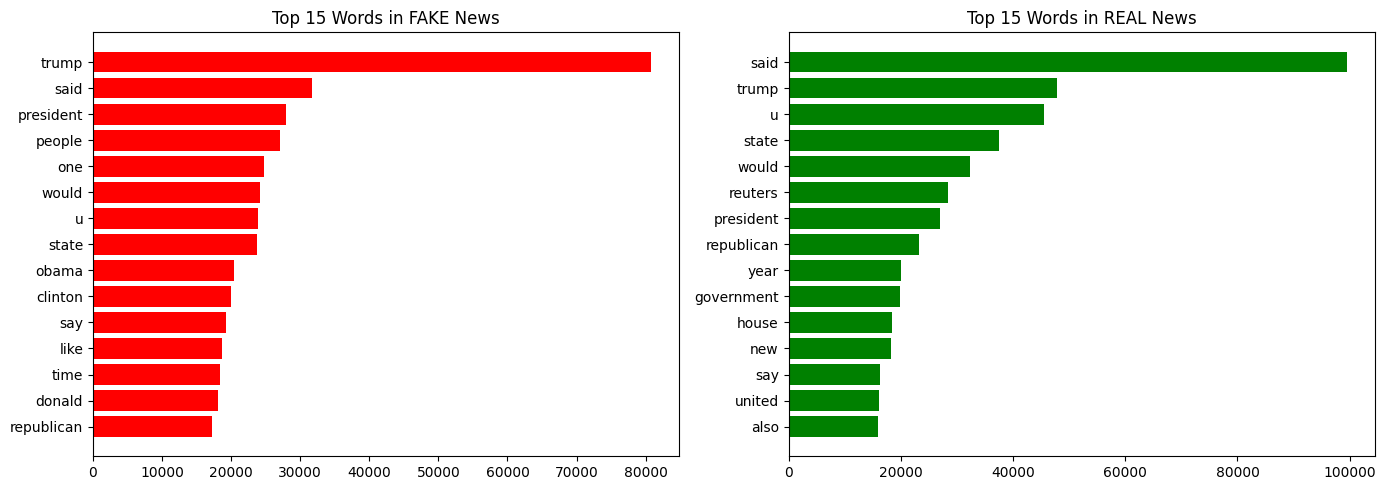

TOP FAKE NEWS WORDS:
      Word  Frequency
     trump      80820
      said      31651
 president      27928
    people      27072
       one      24700
     would      24239
         u      23858
     state      23703
     obama      20452
   clinton      19917
       say      19194
      like      18693
      time      18415
    donald      18034
republican      17196

TOP REAL NEWS WORDS:
      Word  Frequency
      said      99506
     trump      47841
         u      45558
     state      37526
     would      32388
   reuters      28365
 president      26992
republican      23319
      year      20061
government      19827
     house      18393
       new      18295
       say      16269
    united      16076
      also      16018


In [15]:
from collections import Counter

fake_words = ' '.join(df[df['label']==1]['content_clean'].dropna()).split()
real_words = ' '.join(df[df['label']==0]['content_clean'].dropna()).split()

fake_freq = pd.DataFrame(Counter(fake_words).most_common(15), columns=['Word', 'Frequency'])
real_freq = pd.DataFrame(Counter(real_words).most_common(15), columns=['Word', 'Frequency'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].barh(fake_freq['Word'][::-1], fake_freq['Frequency'][::-1], color='red')
axes[0].set_title('Top 15 Words in FAKE News')
axes[1].barh(real_freq['Word'][::-1], real_freq['Frequency'][::-1], color='green')
axes[1].set_title('Top 15 Words in REAL News')
plt.tight_layout()
plt.show()

print("TOP FAKE NEWS WORDS:")
print(fake_freq.to_string(index=False))
print("\nTOP REAL NEWS WORDS:")
print(real_freq.to_string(index=False))

In [16]:
summary = {
    'Metric': ['Accuracy', 'AUC Score', 'Total Samples',
               'Fake Articles', 'Real Articles'],
    'Value': [
        f"{accuracy_score(y_test, preds)*100:.2f}%",
        f"{roc_auc_score(y_test, model.predict_proba(X_test)[:,1]):.4f}",  # ← fix
        len(df),
        len(df[df['label']==1]),
        len(df[df['label']==0])
    ]
}
summary_df = pd.DataFrame(summary)
print(summary_df.to_string(index=False))

       Metric  Value
     Accuracy 91.22%
    AUC Score 0.9774
Total Samples  57689
Fake Articles  29138
Real Articles  28551


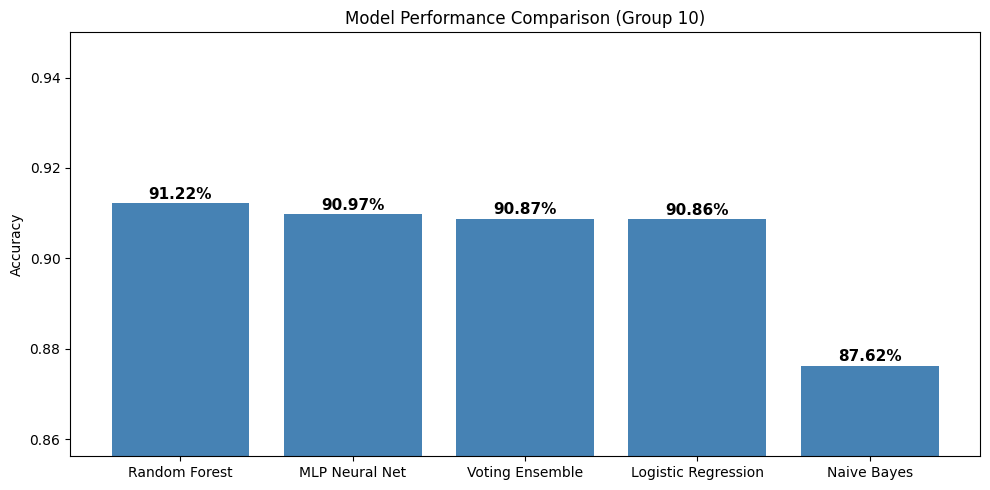

In [17]:
import matplotlib.pyplot as plt

models_compared = {
    'Random Forest': 0.9122,
    'MLP Neural Net': 0.9097,
    'Voting Ensemble': 0.9087,
    'Logistic Regression': 0.9086,
    'Naive Bayes': 0.8762
}

plt.figure(figsize=(10, 5))
bars = plt.bar(models_compared.keys(), models_compared.values(), color='steelblue')

# Dynamic Y-axis limits based on your new data
min_acc = min(models_compared.values())
plt.ylim(min_acc - 0.02, 0.95) 

plt.ylabel('Accuracy')
plt.title('Model Performance Comparison (Group 10)')

# Logic for adding labels on top of the bars
for bar, val in zip(bars, models_compared.values()):
    plt.text(bar.get_x() + bar.get_width()/2, 
             bar.get_height() + 0.001,
             f'{val*100:.2f}%', 
             ha='center', 
             fontsize=11, 
             fontweight='bold')

plt.tight_layout()
plt.show()

In [18]:
test = "Federal Reserve raises interest rates by 0.25 percent"
cleaned = clean_text(test)
print(f"Cleaned: '{cleaned}'")

sample_real = df[df['label']==0]['content_clean'].iloc[0]
print(f"\nSample real article start: '{sample_real[:200]}'")

sample_fake = df[df['label']==1]['content_clean'].iloc[0]
print(f"\nSample fake article start: '{sample_fake[:200]}'")

Cleaned: 'federal reserve raise interest rate percent'

Sample real article start: 'least three dead lidia slam mexico los cabos tourist hub mexico city reuters least three people died torrential rain tropical storm lidia provoked major flooding around mexico popular los cabos beach '

Sample fake article start: 'say offered million saving million saving next year contract negotiation city milwaukee say offered million saving million saving next year contract negotiation city milwaukee'
